<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/Overcome_Overfitting_by_data_augmentation_and_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/

In [ ]:
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
! kaggle datasets list

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                               Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          11769        282                1  
algozee/teenager-menthal-healy                                      Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           2998         70                1  
sumeakash/impact-of-social-media-on-health                          Impact of Social Media on Health                         18598  2026-04-05 06:53:55.953000           2976         72

In [ ]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:09<00:00, 87.1MB/s]



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

In [ ]:
DATA_DIR = "/content/PetImages"   # change if needed
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [ ]:
from PIL import Image
import os

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Found 23410 files belonging to 2 classes.
Using 4682 files for validation.


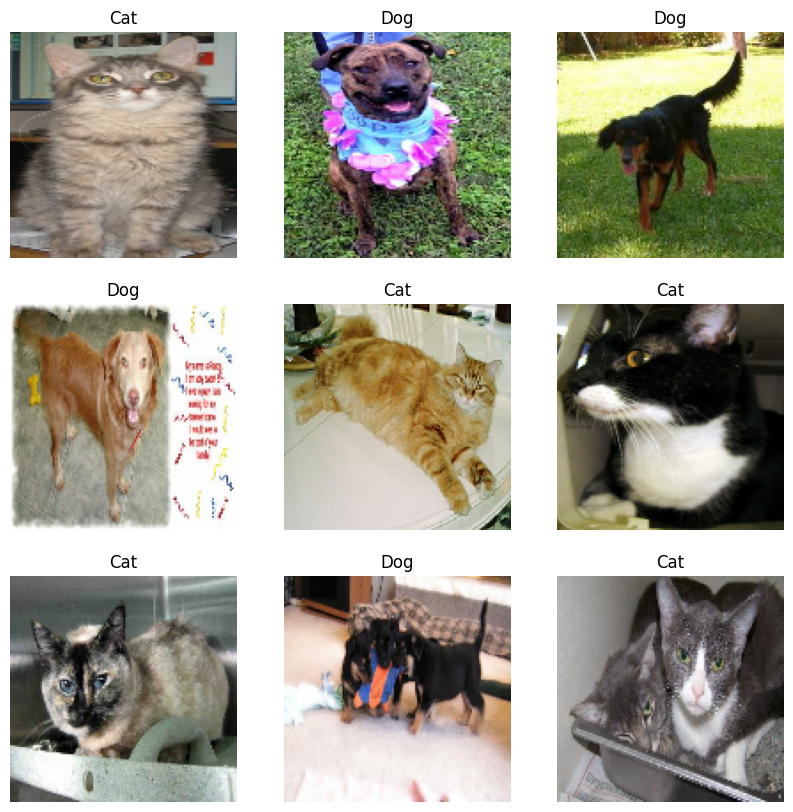

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

class_names = train_ds.class_names # Define class_names here

for images, labels in train_ds.take(12):
    for i in range(9):  # show 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
## Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

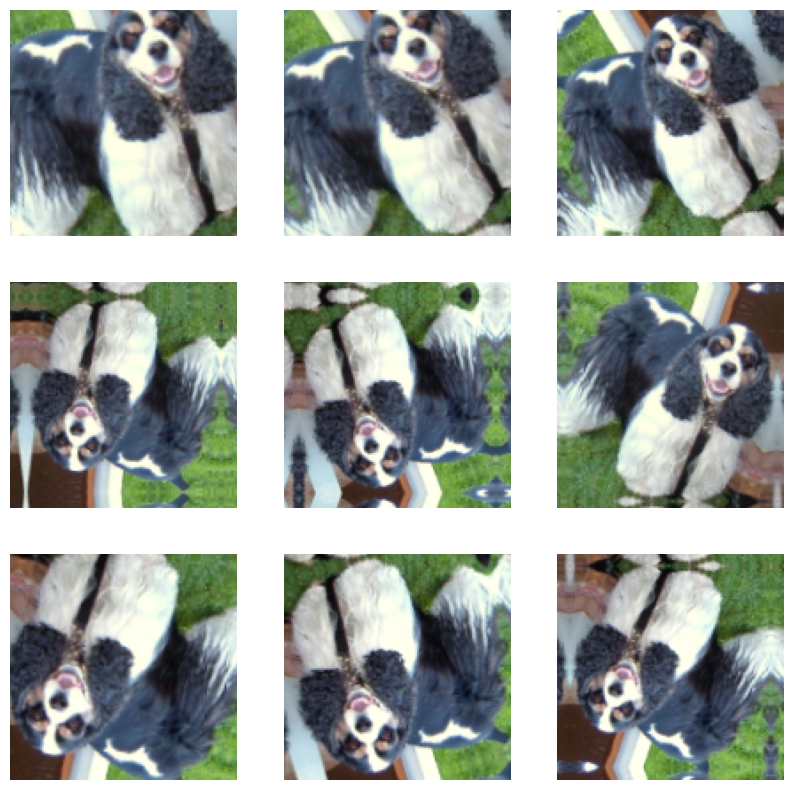

In [ ]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(12):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[4].numpy().astype("uint8"))
        plt.axis("off")

plt.show()

In [ ]:
## Add augmentation & dropout layer to overcome overfitting

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
inputs = keras.Input(shape = (128,128,3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size = 3, activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model= keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 982,593 (3.75 MB)

 Trainable params: 982,593 (3.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="convnet_from_scratch.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [ ]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=callbacks,
)

Epoch 1/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.5662 - loss: 0.6746 - val_accuracy: 0.6877 - val_loss: 0.5951
Epoch 2/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.6700 - loss: 0.6108 - val_accuracy: 0.6954 - val_loss: 0.5891
Epoch 3/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.7021 - loss: 0.5767 - val_accuracy: 0.7245 - val_loss: 0.5463
Epoch 4/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.7253 - loss: 0.5516 - val_accuracy: 0.7196 - val_loss: 0.5479
Epoch 5/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.7389 - loss: 0.5287 - val_accuracy: 0.6074 - val_loss: 0.6565
Epoch 6/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.7552 - loss: 0.5063 - val_accuracy: 0.7384 - val_loss: 0.5388
Epoch 7/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - accuracy: 0.7706 - loss: 0.4840 - val_accuracy: 0.7922 - val_loss: 0.4380
Epoch 8/10
586/586 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.7821 - loss: 0.4659 - 

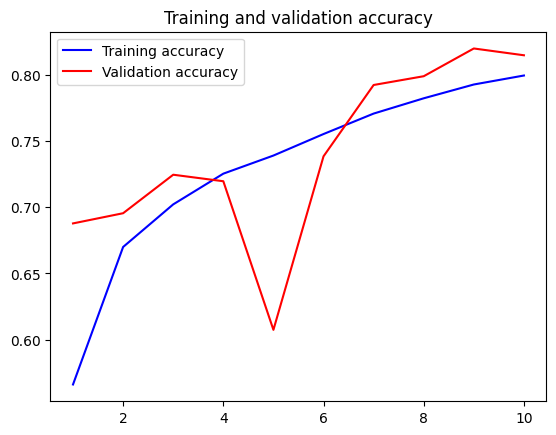

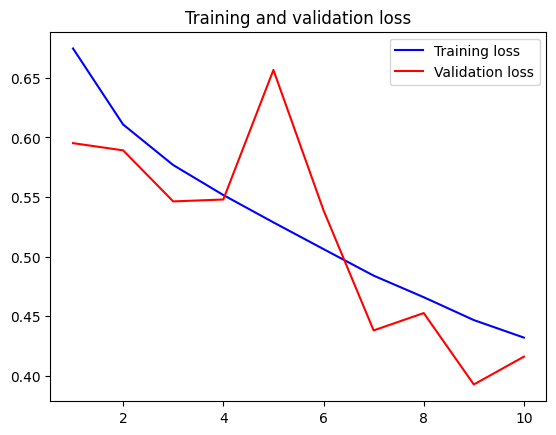

In [ ]:
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy)+1)
plt.plot(epochs, accuracy, "b", label="Training accuracy")
plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()